Group members (first and last names):

Sylvain Lott, Arnaud Haizmann, Sacha Aebischer


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
sns.set(rc={'figure.figsize':(8, 6)}, style='whitegrid')

# Introduction to Unsupervised Learning
Unsupervised learning is a branch of machine learning that deals with finding patterns and structures in unlabeled data. Unlike supervised learning, where the algorithm learns from labeled examples, unsupervised learning algorithms must discover patterns on their own.

This assignment covers:

- Clustering algorithms ($k$-means, DBSCAN)
- Methods for determining optimal cluster numbers
- Dimensionality reduction with PCA
- Practical applications of $k$-means and PCA

This assignment involves extensive plotting. The easiest option for creating plots is `seaborn` because it integrates seamlessly with `pandas`. However, if you're up for a challenge and more control over your visualizations, I highly recommend getting familiar with `matplotlib`. While it has a steeper learning curve, it offers a broader range of customization options to fine-tune your plots.

For help with `matplotlib`, click [here](https://matplotlib.org/stable/tutorials/pyplot.html) 📈


---
## How to pass the assignment?
Below, you will find the exercise questions. Each question that awards points is numbered and displays the available points in this format: **(0 pts)**.

### Answering Questions
- Provide your answers in the cell directly below each question.
- Use **Markdown** for text-based answers (in **English**).
- Use **code cells** for implementations.
- **Incomplete or incorrect answers receive 0 points.** Partial credit may be awarded at the teacher's discretion.
- Overly detailed answers do not grant extra points. Stick to what is asked.

### Critical Thinking Questions and Bonus Exercises
- Some questions are marked with a 🧠 (Critical Thinking) or a ⭐ (Bonus Exercise). These are for self-reflection and extra practice.
- They are **optional** and do **not** award any points.
- Answering them can help reinforce your understanding.

### Important Notes
- Save your work frequently! `(Ctrl + S)`
- Before submitting, `Restart Session and Run All` cells to ensure everything works correctly.
- **You need at least 23 points out of 34 (66%) to pass ✅**
---

# 1. Fundamentals

#### 1.1 **(1pt) Write an example of a Machine Learning application for which the Unsupervised Learning paradigm is an ideal choice.**

Unsupervised learning is ideal for customer segmentation, where businesses analyze customer data to group them into similar categories for personalized marketing, pricing strategies, and product recommendations.

#### 1.2 **(1pt) What is the key difference between Supervised and Unsupervised Learning in terms of data and objectives? Explain in your own words.**

Supervised Learning works with labeled data, meaning each data point comes with an associated output or category. For example, in an email spam filter, emails are labeled as "Spam" or "Not Spam."
Unsupervised Learning works with unlabeled data, meaning there are no predefined categories or labels. The algorithm must discover patterns on its own. For example, in customer segmentation, customers are grouped based on behavior without predefined labels.
In Supervised Learning the goal is to learn from past examples to make predictions or classifications. The algorithm maps input to a known output.
Example: Predicting house prices based on size, location, and other features.
In Unsupervised Learning the goal is to find hidden structures or patterns in data. There is no explicit outcome to predict.
Example: Identifying groups of customers with similar buying habits for targeted marketing.

#### 1.3 **(1pt) Why is evaluating the performance of an Unsupervised Learning model more challenging than for a Supervised Learning model? Provide an example.**

Evaluating the performance of an Unsupervised Learning model is more challenging than for Supervised Learning because there are no predefined labels or correct answers to compare against. In supervised learning, we can measure accuracy, precision, recall, or mean squared error by directly comparing predictions to ground truth labels. In contrast, unsupervised learning models are discovering hidden structures, and there is no absolute way to confirm that these structures are "correct." Suppose an e-commerce company applies k-means clustering to group customers based on purchase behavior. There is no label for "High-Value Customer" or "Budget Shopper" in the dataset. The clusters found by the algorithm may or may not align with meaningful business insights.

---
# 2. Clustering


## K-Means Clustering

#### 2.1 **(3 pts) Explain how the $k$-means algorithm works. What is the goal of the algorithm? Which parameters does the user need to define?**

🤷 Need some help? Check out this [video](https://www.youtube.com/watch?v=4b5d3muPQmA).

The k-means clustering algorithm aims to partition a dataset into k clusters, where each data point belongs to the cluster with the nearest mean (centroid). The goal is to minimize the variance within each cluster, ensuring that similar data points are grouped together.

The parameters that need to be defined by the user are:
- Number of clusters (k)
- Initialization method
  - choosing initial centroids matters
    - random Initialization
    - k-means++
- distance Metric:
  - usually Euclidean distance
- Stopping criteria
  - algorithm stops when centroids stop changing significantly or after a fixed number of iterations



---
Let's see how this works on the `penguins` dataset. Since we have labels, we can check accuracy—but in real UL applications, this isn't usually possible 😉

K-Means assigns random numbers to clusters, so we don’t know which cluster corresponds to which species. To fix this, we test all possible mappings and pick the one that minimizes misclassifications. This lets us evaluate how well K-Means grouped the data.


In [15]:
# Goal: convert the labels to the cluster numbers generated by k-means
import itertools
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load and pre-process Penguins dataset with pandas
penguins = sns.load_dataset('penguins')
penguins.dropna(inplace=True) # drop NA
X = penguins.drop(['species', 'island', 'sex'], axis=1) # remove categorical variables
y = penguins['species'].astype('category').cat.codes # encode labels to integers
labels = penguins['species'].unique() # keep the string labels in a numpy array

species_names = y.unique()

X_scaled = StandardScaler().fit_transform(X) # we need to scale the inputs
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

# Generate all possible permutations of cluster labels
possible_codes = itertools.permutations(range(len(species_names)))
converters = [dict(zip(species_names, perm)) for perm in possible_codes]
# print(converters) # try printing each of these variables and understand what they do

def cluster_to_class(model, fn_that_counts_misclassified, x_test, y_test):
    min_score = np.Infinity
    right_conversion = None
    for converter in converters:
        conv_y_test = y_test.map(converter)
        misclassified = fn_that_counts_misclassified(model, x_test, conv_y_test)
        if misclassified < min_score:
            min_score = misclassified
            right_conversion = converter
    return right_conversion

# Scoring function based on labels
def mis_score_fn(model, X_test, y_test):
    y_hat = model.predict(X_test)
    return np.sum(y_test != y_hat)

# K-Means clustering (fit requires a 2D matrix)
kmeans = KMeans(random_state=42, n_init="auto").fit(X_train)

# Use the cluster_to_class function
right_conversion = cluster_to_class(kmeans, mis_score_fn, X_test, y_test)
conv_y_test = y_test.map(right_conversion)
k_means_misclassified = mis_score_fn(kmeans, X_test, conv_y_test)

# Print results
print('Right Conversion:', right_conversion)
print('Misclassified:', k_means_misclassified)
print('Accuracy:', round((len(y_test) - k_means_misclassified) / len(y_test) * 100, 2), '%')

Right Conversion: {0: 2, 1: 1, 2: 0}
Misclassified: 39
Accuracy: 41.79 %


That doesn't perform very well... do you know why?

#### 2.2 **(1pt) Retrain the K-Means model in the cell below with different parameters to improve the accuracy.**


In [16]:
# K-Means clustering (fit requires a 2D matrix)
retrained_kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto").fit(X_train)

# Use the cluster_to_class function
right_conversion = cluster_to_class(retrained_kmeans, mis_score_fn, X_test, y_test)
conv_y_test = y_test.map(right_conversion)
k_means_misclassified = mis_score_fn(retrained_kmeans, X_test, conv_y_test)

# Print results
print('Right Conversion:', right_conversion)
print('Misclassified:', k_means_misclassified)
print('Accuracy:', round((len(y_test) - k_means_misclassified) / len(y_test) * 100, 2), '%')

Right Conversion: {0: 2, 1: 1, 2: 0}
Misclassified: 5
Accuracy: 92.54 %


#### 2.3 **(3pt) Plot the centroids of both $k$-means models over the `penguins` dataset (side-by-side).**

To get the centroid coordinates, use the `cluster_centers_` attribute of the KMeans object.

A more structured approach is to convert the centroids into a DataFrame:
```
columns = penguins.columns.drop('species')  # Remove species since centroids don’t have labels
centroids_df = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
```
For visibility, you can pass styling options like this:

```
kwargs = {'marker': 'X', 'color': 'r', 's': 200, 'label': 'Centroids'}
```
and use `**kwargs` in scatterplot() to apply them.


The question is open-ended, so choose a meaningful plot. The simplest is `bill_length_mm` vs. `body_mass_g`.

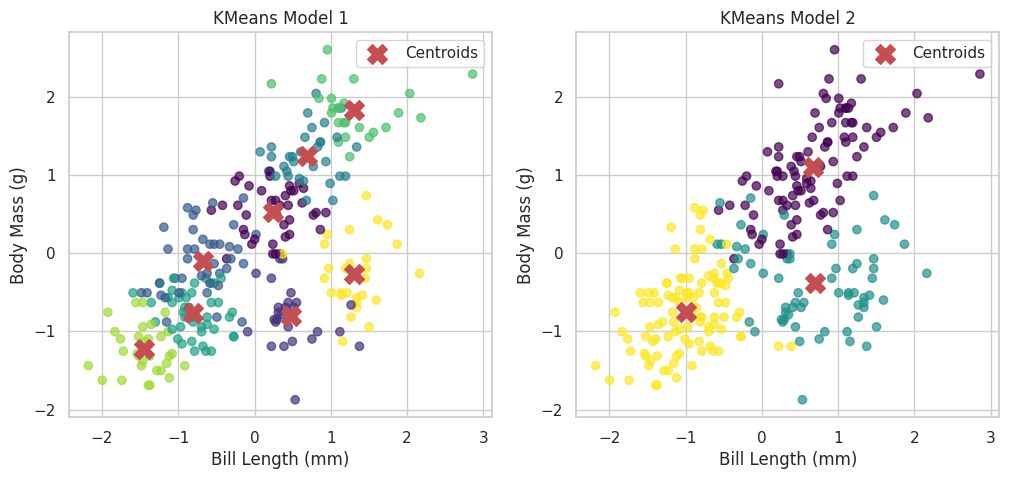

In [17]:
# Get centroids
numerical_columns = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']  # The numerical features
centroids_1 = pd.DataFrame(kmeans.cluster_centers_, columns=numerical_columns)
centroids_2 = pd.DataFrame(retrained_kmeans.cluster_centers_, columns=numerical_columns)

# Create side-by-side plots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Define keyword arguments for centroids
kwargs = {'marker': 'X', 'color': 'r', 's': 200, 'label': 'Centroids'}

# Define a function to plot clusters on top of data with matplotlib
def plot_clusters(ax, X, labels, centroids, title):
    ax.scatter(X['bill_length_mm'], X['body_mass_g'], c=labels, cmap='viridis', alpha=0.7)
    ax.scatter(centroids['bill_length_mm'], centroids['body_mass_g'], **kwargs)
    ax.set_title(title)
    ax.set_xlabel('Bill Length (mm)')
    ax.set_ylabel('Body Mass (g)')
    ax.legend()

# Plot first model
plot_clusters(axes[0], X_train, kmeans.labels_, centroids_1, 'KMeans Model 1')

# Plot second model
plot_clusters(axes[1], X_train, retrained_kmeans.labels_, centroids_2, 'KMeans Model 2')

plt.show()

#### 🧠 Critical Thinking

- What would happen if we ran the K-means algorithm multiple times with a different `random state`?
- We trained the $k$-means model using all four continuous features of the penguins dataset, but we only plotted the centroids for two of them. Is this a valid approach? Why or why not?

#### ⭐ Bonus: Create a visualization that explores all feature relationships in the penguins dataset using a `PairGrid`. Display scatterplots for off-diagonal relationships, color points by cluster, and show feature distributions on the diagonal using `kdeplot()`.

In [18]:
# Fit K-Means model (on entire dataset)


# Create a PairGrid


# Use kdeplot for diagonal distributions


# Use scatterplot for off-diagonal relationships


# Add legend


---
## Choosing the Number of Clusters

Alright, let's work with some true unlabelled data and try out various clustering algorithms.

First, let's generate some data and then explore how we can choose the number of clusters to pass to the algorithms.

- **Elbow Method**: Plot inertia vs. $k$ and identify the "elbow" point.

- **Silhouette Score**: Measures cluster compactness and separation.


### Generate Data
Let's pretend we have ✨ *no clue* ✨ how many clusters exist.

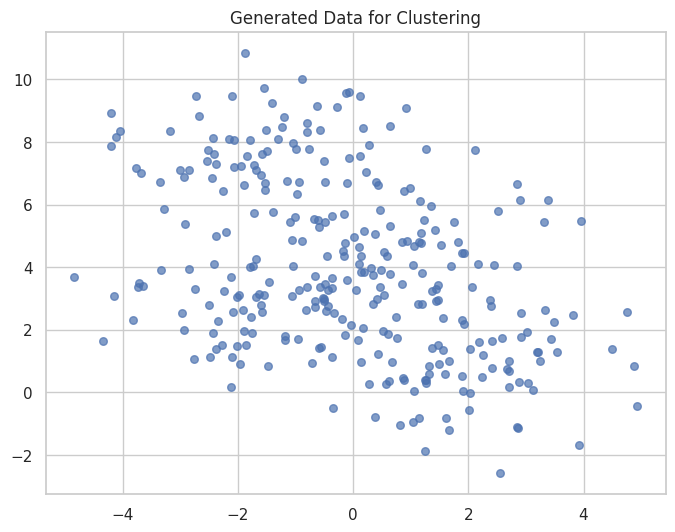

In [19]:
from sklearn.datasets import make_blobs

# Generate synthetic data (X is a 2D matrix)
n_clusters = 4
X, _ = make_blobs(n_samples=300, centers=n_clusters, cluster_std=1.25, random_state=0)

# Plot the data
plt.scatter(X[:, 0], X[:, 1], s=30, alpha=0.7)
plt.title("Generated Data for Clustering")
plt.show()


Visually, the clusters appear to merge into a single dense region, making it difficult to distinguish clear boundaries between them.

### Method 1: Using the Elbow Method
The elbow method helps to determine the optimal number of clusters by plotting the sum of squared distances (inertia) from each point to its assigned cluster center. The optimal number of clusters is typically where the "elbow" occurs, indicating a point after which adding more clusters doesn’t result in a significant reduction in inertia.

**How it works:**
1. Implement K-Means clustering for a range of cluster numbers.
2. For each number of clusters, calculate the inertia (within-cluster sum of squares).
3. Plot the inertia against the number of clusters to visualize the elbow.

**Interpretation:**
-  Visually identify where the inertia starts to decrease at a slower rate (the elbow). This is likely the optimal number of clusters.

Hint: You can use `KMeans` from `sklearn.cluster` and `inertia_` to get the sum of squared distances.

#### 2.4 **(1pt) In the elbow plot  created below, where do you think the optimal number of clusters should be? Highlight this point on the graph by filling in the missing parts of the code.**

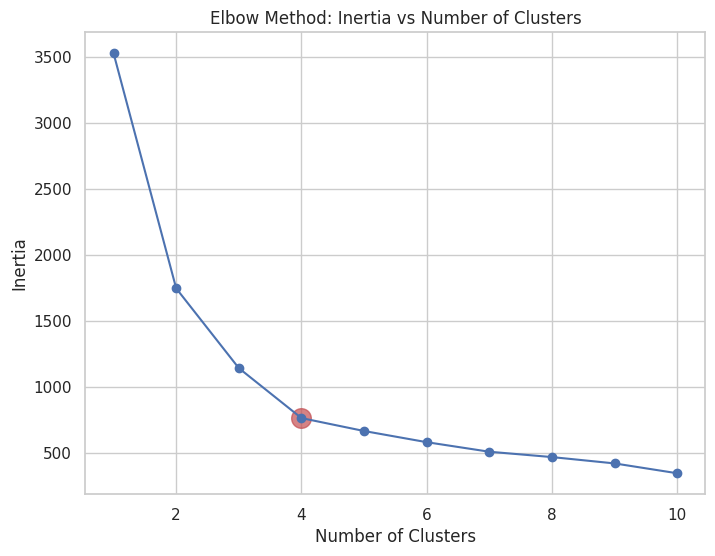

In [20]:
# Make sure you understand this code
inertia_values = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)

# Plot the elbow graph
plt.scatter(x=[cluster_range[3]], y=inertia_values[3], s=200, color='r', alpha=0.7) # highlight the point with the correct number of clusters
plt.plot(cluster_range, inertia_values, marker='o')
plt.title('Elbow Method: Inertia vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()


### Method 2: Using the Silhouette Score
The **silhouette score** measures how well a data point fits into its assigned cluster by comparing its average distance to points in the same cluster (**a**) versus the closest other cluster (**b**). It ranges from **-1 to 1**, where higher values mean well-separated clusters, and it is usually calculated using **Euclidean distance** to determine cohesion (tightness) and separation (distance from other clusters).

**How it works:**
1. For each number of clusters (e.g., 1 to 10), calculate the silhouette score.
2. Plot the silhouette score against the number of clusters to find the optimal number.

**Interpretation:**
- Visually identify the number of clusters that results in the highest silhouette score. This number should be considered the optimal cluster count, particularly if it coincides with the elbow method.

Hint: You can use `silhouette_score` from `sklearn.metrics` to calculate the score.

#### 2.5 **(1pt) In the silhouette score plot created below, where do you think the optimal number of clusters should be? Highlight this point on the graph by filling in the missing parts of the code.**

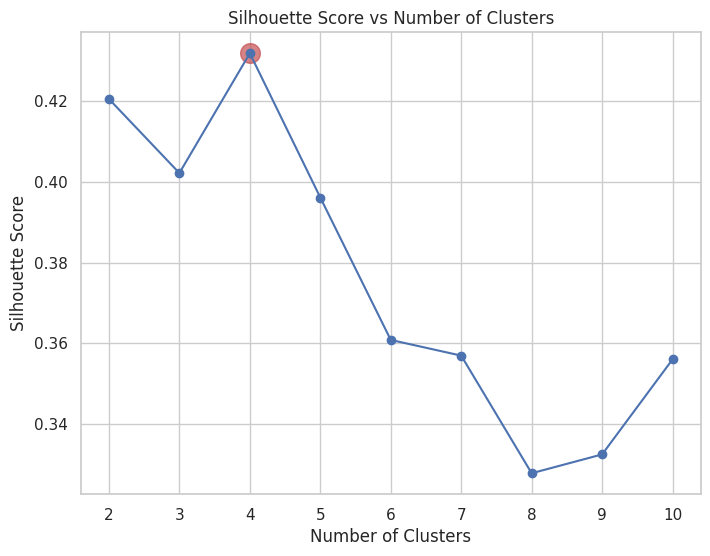

In [21]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in cluster_range[1:]:  # Skipping k=1 because silhouette score is not defined for a single cluster
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_, metric='euclidean')
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.scatter(x=[cluster_range[3]], y=silhouette_scores[2], s=200, color='r', alpha=0.7) # highlight the point with the correct number of clusters
plt.plot(cluster_range[1:], silhouette_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()


---
## DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**Theory**

DBSCAN is a density-based clustering algorithm that groups together points that are closely packed together, marking points in low-density regions as outliers.

**Key Concepts:**
- **Core Point:** A point with at least `min_samples` points within distance `eps`
- **Border Point:** A point within distance `eps` of a core point but with fewer than `min_samples` neighbors
- **Noise Point:** A point that is neither a core point nor a border point

**Here's how it works:**
1. For each point, determine if it's a core point
2. Connect all core points that are within distance `eps` of each other
3. Form clusters from connected core points
Assign each border point to the cluster of its neighboring core point
4. Designate all remaining points as noise

🤷 Need some help? Check out this [video](https://www.youtube.com/watch?v=RDZUdRSDOok&ab_channel=StatQuestwithJoshStarmer).

#### 2.6 **(13pts) Use scikit-learn to apply DBSCAN and K-Means on the generated data below and plot the results according to the instructions below using `matplotlib`.**

**DBSCAN parameters:**
- `eps = 0.2`
- `min_samples = 5`

**K-means parameters:**
- `n_clusters = 2`
- `random_state = 42`

**Instructions:**
1. Apply DBSCAN to both datasets and plot the results in the left column of a 2x2 grid (4pts).
2. Apply K-means clustering to both datasets and plot the results in the right column of the same 2x2 grid (4pts).
3. For K-means, also plot the cluster centers as distinct markers (1pt).
4. Make sure to color-code the clusters by their labels in both DBSCAN and K-means plots, so that the different clusters are visually distinguishable (1pt).
5. Make sure to include a title for each subplot to indicate which clustering algorithm and dataset is being displayed (1pt).
6. Include the silhouette score in each subplot title by calculating it for both DBSCAN and K-means using Euclidean distance. Round the score to 2 decimal points (2pts).

In [22]:
from sklearn.datasets import make_moons, make_circles
from sklearn.cluster import DBSCAN

# Generate datasets
n_samples = 300

# Dataset 1: Concentric circles
X_circles, _ = make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=42)

# Dataset 2: Moon-shaped clusters
X_moons, _ = make_moons(n_samples=n_samples, noise=0.05, random_state=42)


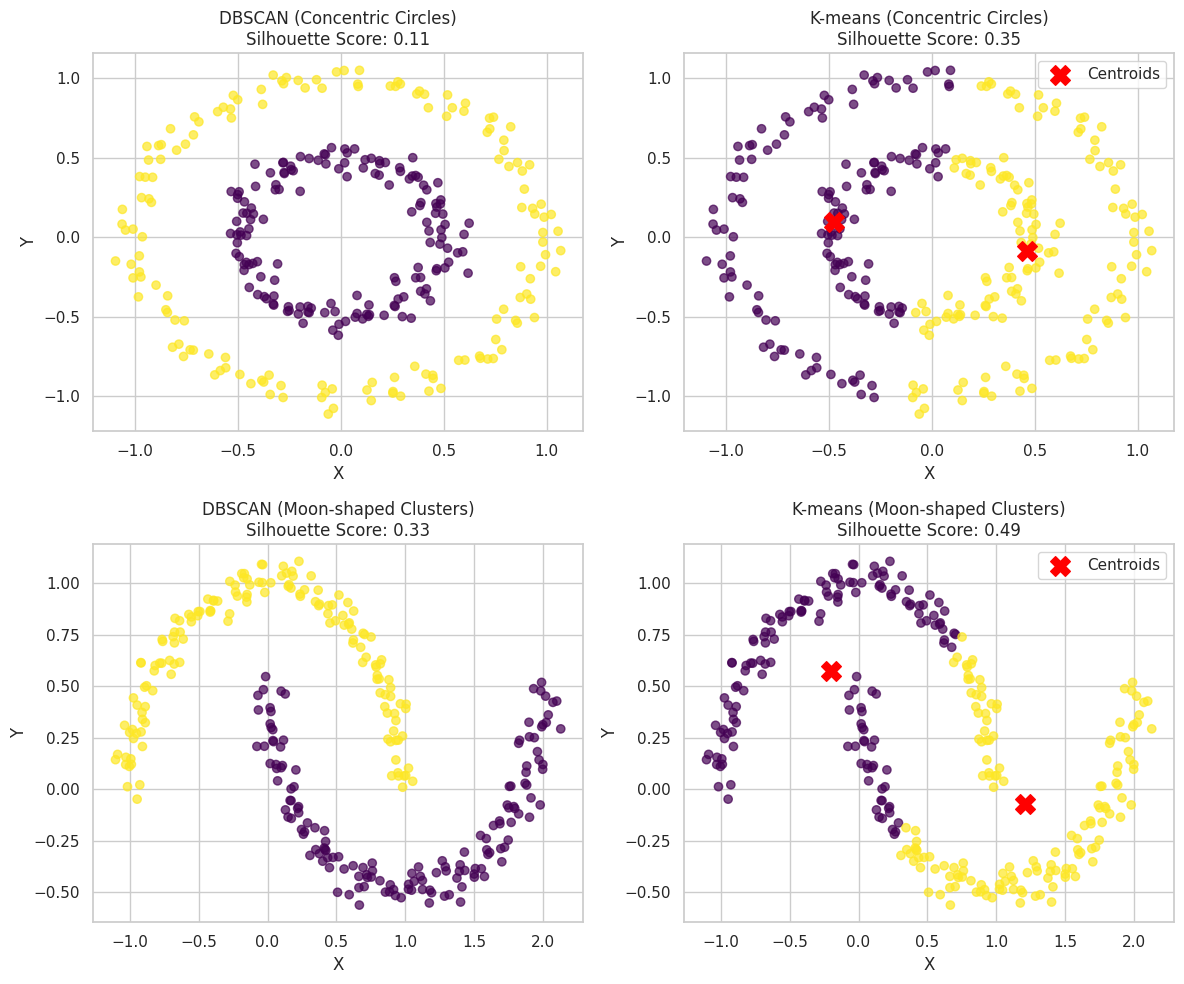

In [23]:
# Apply DBSCAN and K-means
datasets = [X_circles, X_moons]
titles = ['Concentric Circles', 'Moon-shaped Clusters']

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

for i, data in enumerate(datasets):
    # DBSCAN (eps=0.2, min_samples=5)
    dbscan = DBSCAN(eps=0.2, min_samples=5)
    dbscan_labels = dbscan.fit_predict(data)
    dbscan_silhouette = silhouette_score(data, dbscan_labels) if len(set(dbscan_labels)) > 1 else -1

    # K-means (k=2, random_state=42)
    kmeans = KMeans(n_clusters=2, random_state=42)
    kmeans_labels = kmeans.fit_predict(data)
    kmeans_centers = kmeans.cluster_centers_
    kmeans_silhouette = silhouette_score(data, kmeans_labels)

    # Plot DBSCAN (Hint: ax[i, 0])
    ax[i, 0].scatter(data[:, 0], data[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.7)
    ax[i, 0].set_title(f"DBSCAN ({titles[i]})\nSilhouette Score: {dbscan_silhouette:.2f}")
    ax[i, 0].set_xlabel('X')
    ax[i, 0].set_ylabel('Y')

    # Plot K-means (Hint: ax[i, 1])
    ax[i, 1].scatter(data[:, 0], data[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
    ax[i, 1].scatter(kmeans_centers[:, 0], kmeans_centers[:, 1], marker='X', color='red', s=200, label='Centroids')
    ax[i, 1].set_title(f"K-means ({titles[i]})\nSilhouette Score: {kmeans_silhouette:.2f}")
    ax[i, 1].set_xlabel('X')
    ax[i, 1].set_ylabel('Y')
    ax[i, 1].legend()

plt.tight_layout()
plt.show()

2.7 **(1pt) Does the silhouette score, based on Euclidean distance, accurately reflect the clustering quality for both DBSCAN and K-means in the above datasets, or are there cases where visual inspection (eye-balling) provides a better assessment?**

No the silhouette score doesn't accurately reflect clustering quality here, we can see visually that DBSCAN got the clusters right while K-means did not. But the silhouette score was higher on the K-means than on the DBSCAN. That's because the clusters are not compact, they are spread out while staying visually separated. But for a high silhouette score clusters need to be compact, therefore as K-means assumes spherical clusters, K-means clusters naturally tend to get higher silhouette scores than DBSCAN as DBSCAN will detect clusters with arbitrary shapes.

---
# 3. PCA (Principal Component Analysis)

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the data into a new coordinate system. The new coordinates (principal components) are ordered by the amount of variance they explain.

**Algorithm:**
1. Standardize the data
2. Compute the covariance matrix
3. Calculate eigenvectors and eigenvalues of the covariance matrix
4. Sort eigenvectors by decreasing eigenvalues
5. Choose top k eigenvectors to form a projection matrix
6. Transform the original data using the projection matrix

🤷 Need some help? Check out this [video](https://www.youtube.com/watch?v=HMOI_lkzW08&ab_channel=StatQuestwithJoshStarmer).


#### 3.1 **(3pt) Plot the entire penguins dataset (no split, keep the classes) projected into 2 dimensions using PCA. Use scikit-learn to compute the principal components.**

**Instructions:**
- Don't forget to standardize the data before applying PCA using `StandardScalar()`.
- Try to use `matplotlib` for plotting. It's more challenging than `seaborn` but it's a great skill to have.
- Add labels to the plot, `xlabel` should be 'PC1' and `ylabel` should be 'PC2'.
- Add the explained variance to the x and y labels. You can find them with `pca.explained_variance_ratio_`.
- To color-code a plot according to the labels in `matplotlib` you must pass the parameter `c` an array of numbers. Remember that you can convert string labels by using `df['y'].astype('category').cat.codes`

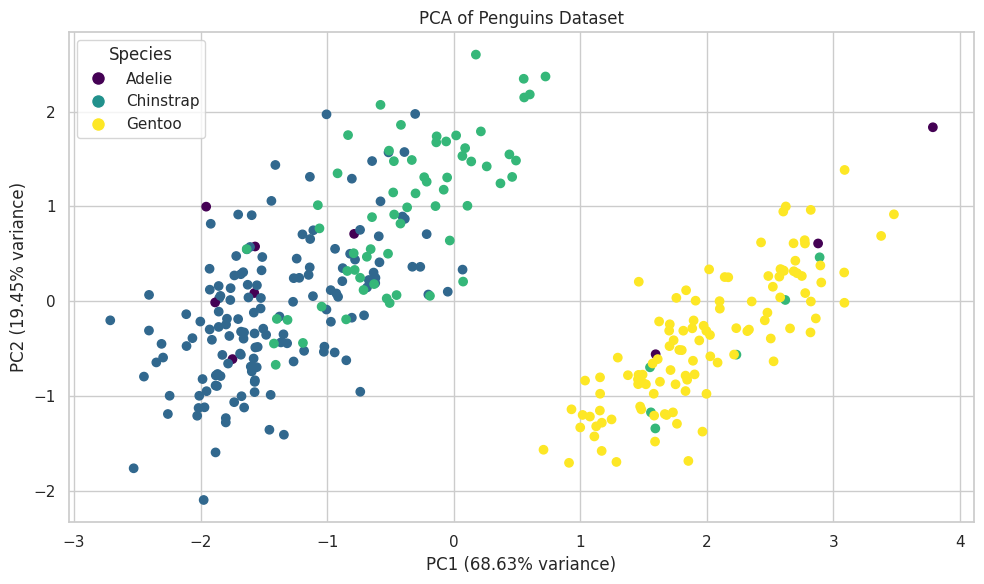

In [24]:
from sklearn.decomposition import PCA

# Load the penguins dataset
penguins = sns.load_dataset('penguins')
penguins = penguins.dropna()
X = penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply scikit-learn PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['species'] = penguins['species']

# Plot scikit-learn PCA
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['species'].astype('category').cat.codes, cmap='viridis')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')

cmap = plt.cm.viridis
species = penguins['species'].unique()

handles = []
for i, species_name in enumerate(species):
    handle = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=cmap(i / (len(species) - 1)), markersize=10)
    handles.append(handle)


plt.legend(handles=handles, labels=species.tolist(), title="Species")
plt.title('PCA of Penguins Dataset')

plt.tight_layout()
plt.show()


#### 3.2 **(5pt) Using the penguins dataset, perform K-means clustering on the scaled data. Print the silhouette score for the K-means clustering. Then, visualize the clustering results in a 2D PCA space by creating two subplots:**

**Instructions:**
- The first subplot should show the K-means clustering labels, with the centroids of the clusters plotted in PCA space.
- Print the silhouette score.
- The second subplot should display the true species labels, with the same centroids plotted in PCA space.
- Make sure to label the axes with the percentage of variance explained by the first two principal components and include the centroids in both subplots.
- Finally, describe the results:
  - Did the K-means algorithm successfully cluster the data?
  - How do the K-means clusters compare with the true species labels (visually and silhouette score)?

❗Remember, the species labels are randomized due to the initialization of $k$-means, so the colors in the $k$-means clustering plot may not correspond directly to the true species labels.

**❓Hint:**

To add legends for the K-means clusters and true species labels, use the `legend_elements()` method from the scatter plot objects. The `legend_elements()` returns a tuple with the handles (plotting objects) and the labels. After plotting the data in both subplots, call `legend_elements()` on the `scatter1` and `scatter2` objects, and then pass the returned legend handles and labels to `ax1.legend()` and handles only to `ax2.legend()` so we can use the string labels.

Ensure you include the centroids in the legends by specifying the appropriate label in the `scatter()` call for the centroids.

```
legend1 = ax1.legend(*scatter1.legend_elements(), title="K-means Clusters") # labels found by KMeans
legend2 = ax2.legend(handles=scatter2.legend_elements()[0], labels=list(labels), title="Species") # True labels
```









Silhouette Score for K-means clustering: 0.446


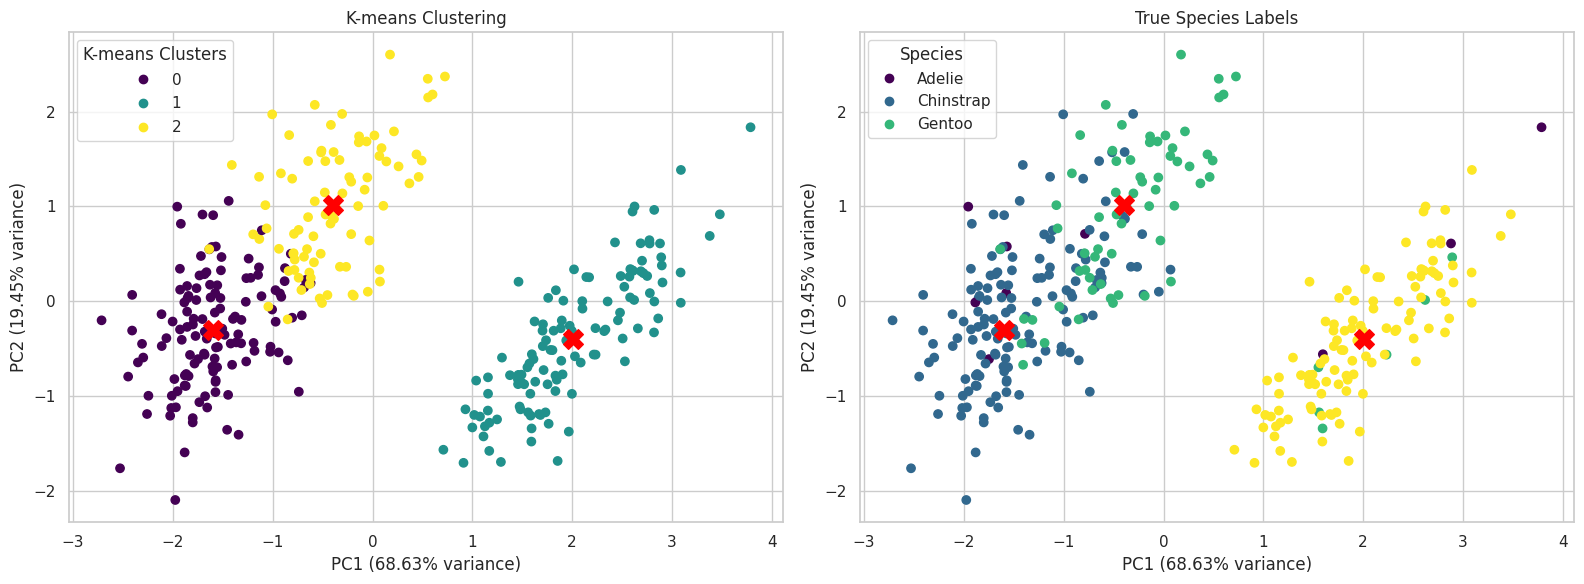

In [25]:
# Run K-means on the SCALED data (not PCA data)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Print the Silhouette Score
silhouette_avg = silhouette_score(X_scaled, kmeans_labels)
print(f'Silhouette Score for K-means clustering: {silhouette_avg:.3f}')

# CRITICAL STEP: Transform centroids to PCA space
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Species found by KMeans clustering
scatter1 = ax1.scatter(df_pca['PC1'], df_pca['PC2'], c=kmeans_labels, cmap='viridis', label="K-means Clusters")
ax1.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label="Centroids")
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)')
ax1.set_title('K-means Clustering')

# Right plot: Data colored by true species
scatter2 = ax2.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['species'].astype('category').cat.codes, cmap='viridis', label="True Species")
ax2.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label="Centroids")
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)')
ax2.set_title('True Species Labels')


# Legends
legend1 = ax1.legend(*scatter1.legend_elements(), title="K-means Clusters")
handles, _ = scatter2.legend_elements()
species_labels = penguins['species'].unique()
legend2 = ax2.legend(handles=handles[:3], labels=species_labels.tolist(), title="Species")

plt.tight_layout()
plt.show()

---
# Conclusion and Further Resources  

In this assignment, we explored **Unsupervised Learning**, focusing on **clustering** and **Principal Component Analysis (PCA)**. These techniques help uncover hidden patterns in data without labeled examples. Clustering, such as K-Means, groups similar data points, while PCA reduces dimensionality to simplify analysis and visualization. Though powerful, both methods have limitations—clustering requires careful parameter selection, and PCA can obscure important information.

To deepen your understanding, explore these tutorials:  

1. [**K-Means for Image Segmentation**](https://www.kaggle.com/code/viktorreichert/k-means-tumor-image-segmentation) – Learn how clustering is applied in medical imaging by segmenting a brain tumor.  
2. [**PCA in Practice**](http://bebi103.caltech.edu.s3-website-us-east-1.amazonaws.com/2015/tutorials/r5_pca.html) – Gain hands-on experience with PCA and understand its pitfalls. The final discussion highlights a crucial lesson—**dimensionality reduction hides information**. Misinterpreting PCA plots can lead to major mistakes, as illustrated by a sarcastic example of searching for "the perfect human." Always remember: every tool has its strengths and weaknesses, and blind reliance on algorithms can be risky.  

Make sure to engage with these resources critically—understanding the consequences of your methods is just as important as learning how to use them!